# I - Imports

In [1]:
import numpy as np
import os
import pandas as pd
from IPython.display import display
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from itertools import product

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [2]:
# Setting up the root directory
root_dir = r"C:\Users\Source\OneDrive - IESEG\Desktop\MBD\ML\Kaggle_Competition"

os.chdir(root_dir)

os.getcwd()

'C:\\Users\\Source\\OneDrive - IESEG\\Desktop\\MBD\\ML\\Kaggle_Competition'

# II - Loading

In [19]:
train = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'train_preprocessed_v2.csv'), index_col="ID")
train_labels = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'y_train.csv'))
test = pd.read_csv(os.path.join(root_dir, 'data', 'processed', 'test_preprocessed_v2.csv'), index_col="ID")

In [20]:
# Verifying the imports
display(train.head(3))
display(train_labels.head(3))
display(test.head(3))

,Var2,Var3,Var5,Var6,Var7,Var8,Var9,Var10,Var11,Var13,...,Var14992_is_missing,Var14994_is_missing,Var14995_is_missing,Var14996_is_missing,Var14997_is_missing,Var14998_is_missing,Var14999_is_missing,Var15000_is_missing,row_missing_count,row_missing_pct
ID,,,,,,,,,,,,,,,,,,,,,
502504,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,458,3.053333
197332,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,527,3.513333
277830,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,0,1,1,460,3.066667


,ID,Target_appetency
0,502504,0
1,197332,0
2,277830,0


,Var2,Var3,Var5,Var6,Var7,Var8,Var9,Var10,Var11,Var13,...,Var14992_is_missing,Var14994_is_missing,Var14995_is_missing,Var14996_is_missing,Var14997_is_missing,Var14998_is_missing,Var14999_is_missing,Var15000_is_missing,row_missing_count,row_missing_pct
ID,,,,,,,,,,,,,,,,,,,,,
877149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,0,1,1,473,3.153333
109603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,501,3.340000
560424,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,0,0,1,1,1,1,504,3.360000


# III - Modeling

## A) Setup

In [21]:
X_train = train.copy()
y_train_arr = train_labels['Target_appetency'].values

# Class imbalance ratio
neg = (y_train_arr == 0).sum()
pos = (y_train_arr == 1).sum()
scale_pos = neg / pos

# our k fold cv 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Computes out-of-fold predictions, then prints classification report and plots confusion matrix. threshold=0.5 is the default probability cutoff.


In [35]:
def evaluate_cv_classifier(model_name, estimator, X, y, cv, threshold=0.5, n_jobs=-1):
    y_proba = cross_val_predict(
        estimator,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=n_jobs)[:, 1]

    y_pred = (y_proba >= threshold).astype(int)

    print(f"\n{model_name}  Classification Report")
    print(classification_report(y, y_pred, digits=4))

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No appetency", "Appetency"])
    
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} - Confusion Matrix, threshold={threshold}")
    plt.show()

    return y_proba, y_pred

## B) DT

In [ ]:
# No scaling, no PCA needed.
# class_weight='balanced' handles imbalance by reweighting splits.
# SMOTE not used for trees as class_weight is more principled as it directly adjusts the impurity criterion, whereas SMOTE generates synthetic points that can mislead tree splits.

dt_pipeline = Pipeline([('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42))])

dt_grid = {
    'dt__max_depth': [3, 5, 10],
    'dt__min_samples_leaf': [20, 50],
    'dt__criterion': ['gini'],
    'dt__ccp_alpha': [0.0, 0.001]
}

dt_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=2,
    verbose=1,
    refit=True
)
dt_search.fit(X_train, y_train_arr)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [37]:
print(f"Best AUC (CV): {dt_search.best_score_:.4f}")
print(f"Best params: {dt_search.best_params_}")

dt_pred = dt_search.best_estimator_.predict_proba(test)[:, 1]

Best AUC (CV): 0.8193
Best params: {'dt__ccp_alpha': 0.0, 'dt__criterion': 'gini', 'dt__max_depth': 3, 'dt__min_samples_leaf': 20}



Decision Tree  Classification Report
              precision    recall  f1-score   support

           0     0.9933    0.7975    0.8847     29466
           1     0.0593    0.7041    0.1094       534

    accuracy                         0.7958     30000
   macro avg     0.5263    0.7508    0.4970     30000
weighted avg     0.9767    0.7958    0.8709     30000



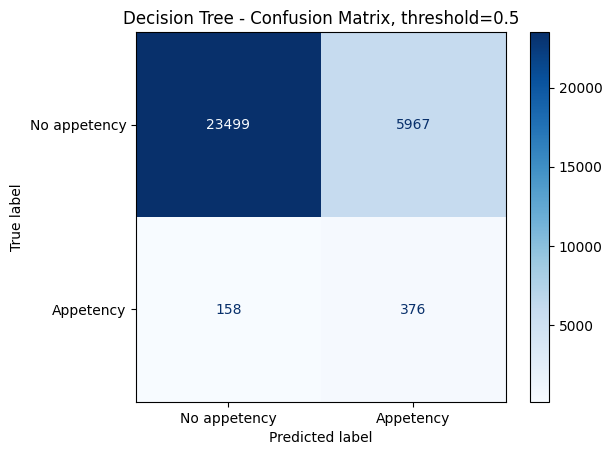

In [38]:
dt_cv_proba, dt_cv_pred = evaluate_cv_classifier(
    "Decision Tree",
    dt_search.best_estimator_,
    X_train,
    y_train_arr,
    cv,
    threshold=0.5
)

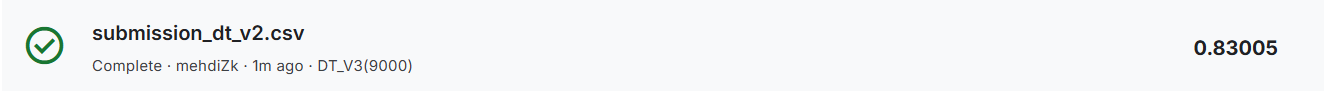

## C) Bagging

In [11]:
# Bagging with DT base estimators.
# max_features and max_samples add randomness on top of bootstrap.
# class_weight passed to base estimator handles imbalance.

base_dt = DecisionTreeClassifier(
    class_weight='balanced',
    criterion='gini',
    max_depth=3,
    min_samples_leaf=20,
    ccp_alpha=0.0,
    random_state=42
)

bag_pipeline = Pipeline([('bagging', BaggingClassifier(estimator=base_dt, random_state=42))])

bag_grid = {
    'bagging__n_estimators': [50, 100],
    'bagging__max_samples': [0.7, 1.0],
    'bagging__max_features': [0.5, 0.7]
}

bag_search = GridSearchCV(
    estimator=bag_pipeline,
    param_grid=bag_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True
)
bag_search.fit(X_train, y_train_arr)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bagging__max_features': [0.5, 0.7], 'bagging__max_samples': [0.7, 1.0], 'bagging__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [31]:
print(f"Best AUC (CV): {bag_search.best_score_:.4f}")
print(f"Best params:  {bag_search.best_params_}")

bag_pred = bag_search.best_estimator_.predict_proba(test)[:, 1]

Best AUC (CV): 0.8601
Best params:  {'bagging__max_features': 0.5, 'bagging__max_samples': 1.0, 'bagging__n_estimators': 100}



Bagging  Classification Report
              precision    recall  f1-score   support

           0     0.9935    0.8307    0.9048     29466
           1     0.0697    0.7004    0.1268       534

    accuracy                         0.8283     30000
   macro avg     0.5316    0.7655    0.5158     30000
weighted avg     0.9771    0.8283    0.8910     30000



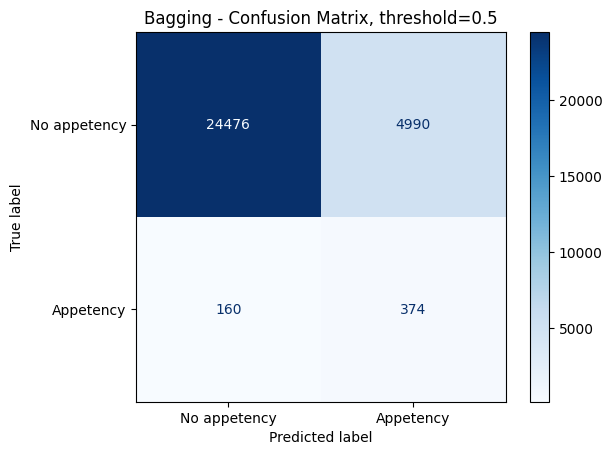

In [36]:
bag_best = bag_search.best_estimator_
bag_best.set_params(bagging__n_jobs=1)

bag_cv_proba, bag_cv_pred = evaluate_cv_classifier(
    "Bagging",
    bag_best,
    X_train,
    y_train_arr,
    cv,
    threshold=0.5,
    n_jobs=1
)

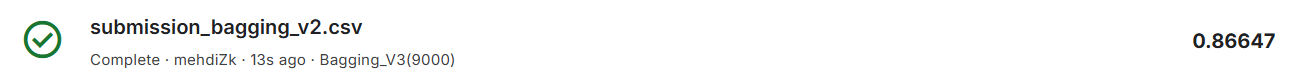

## D) RF

In [41]:
# max_features='sqrt' is the standard RF rule for classification.
# class_weight='balanced_subsample' recomputes weights on each
# bootstrap sample — more appropriate than 'balanced' for RF
# since each tree sees a different bootstrap sample.

rf_pipeline = Pipeline([
    ('rf', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

rf_grid = {
    'rf__n_estimators': [100, 300],
    'rf__max_depth': [10],
    'rf__max_features': ['sqrt', 0.1],
    'rf__min_samples_leaf': [5, 20]
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=2,
    verbose=1,
    refit=True
)
rf_search.fit(X_train, y_train_arr)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [10], 'rf__max_features': ['sqrt', 0.1], 'rf__min_samples_leaf': [5, 20], 'rf__n_estimators': [100, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [42]:
print(f"Best AUC (CV): {rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")

rf_pred = rf_search.best_estimator_.predict_proba(test)[:, 1]

Best AUC (CV): 0.8600
Best params: {'rf__max_depth': 10, 'rf__max_features': 0.1, 'rf__min_samples_leaf': 5, 'rf__n_estimators': 300}



Random Forest  Classification Report
              precision    recall  f1-score   support

           0     0.9871    0.9823    0.9847     29466
           1     0.2312    0.2940    0.2589       534

    accuracy                         0.9700     30000
   macro avg     0.6092    0.6381    0.6218     30000
weighted avg     0.9737    0.9700    0.9718     30000



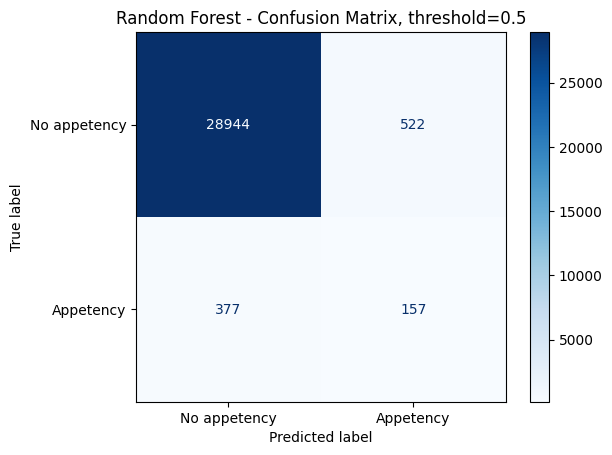

In [43]:
rf_cv_proba, rf_cv_pred = evaluate_cv_classifier("Random Forest", rf_search.best_estimator_, X_train, y_train_arr, cv, threshold=0.5)

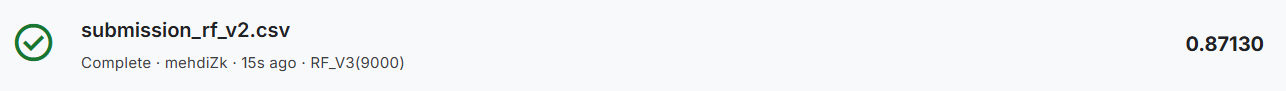

# IV - Model Comparison

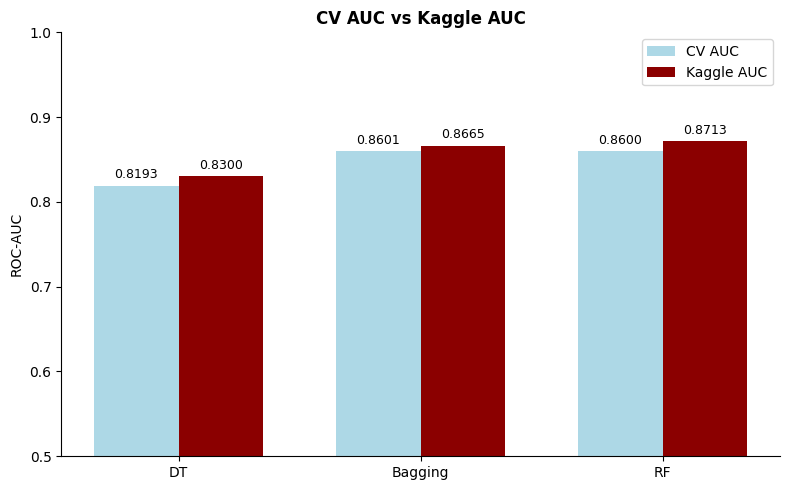

In [47]:
#  CV AUC vs Kaggle AUC

kaggle_scores = {
    "DT":  0.83005,   
    "Bagging": 0.86647,   
    "RF": 0.87130,   
}

models = ["DT", "Bagging", "RF"]
cv_aucs = [dt_search.best_score_, bag_search.best_score_, rf_search.best_score_]
kag_aucs = [kaggle_scores[m] if kaggle_scores[m] is not None else float("nan") for m in models]

x= np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_cv  = ax.bar(x - width / 2, cv_aucs,  width, label="CV AUC", color="lightblue")
bars_kag= ax.bar(x + width / 2, kag_aucs, width, label="Kaggle AUC", color="darkred")

ax.set_ylabel("ROC-AUC")
ax.set_title("CV AUC vs Kaggle AUC", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.5, 1)
ax.legend()

# adding the values on top of the bars
for bar in bars_cv:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars_kag:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

plt.show()

## Exporting the submission CSVs

In [ ]:
# Export Kaggle submission files for DT, Bagging, and RF

submission_dt = pd.DataFrame({
    "ID":  test.index,
    "Target_appetency": dt_pred
})

submission_bagging = pd.DataFrame({
    "ID":  test.index,
    "Target_appetency": bag_pred
})

submission_rf = pd.DataFrame({
    "ID":  test.index,
    "Target_appetency": rf_pred
})

submission_dt.to_csv("output/submission_dt_v2.csv", index=False)
submission_bagging.to_csv("output/submission_bagging_v2.csv", index=False)
submission_rf.to_csv("output/submission_rf_v2.csv", index=False)


display(submission_dt.head())
display(submission_bagging.head())
display(submission_rf.head())

,ID,Target_appetency
0,877149,0.588927
1,109603,0.366290
2,560424,0.341996
3,386592,0.366290
4,857379,0.588927


,ID,Target_appetency
0,877149,0.615435
1,109603,0.333446
2,560424,0.265604
3,386592,0.347479
4,857379,0.560344


,ID,Target_appetency
0,877149,0.315072
1,109603,0.029967
2,560424,0.034315
3,386592,0.053908
4,857379,0.202126
